## Implementasi Regresi Linier dan Regresi Polinomial

### Dataset Sintesis

Implementasi regresi linier dan regresi polinomial tanpa menggunakan library machine learning seperti scikit-learn.

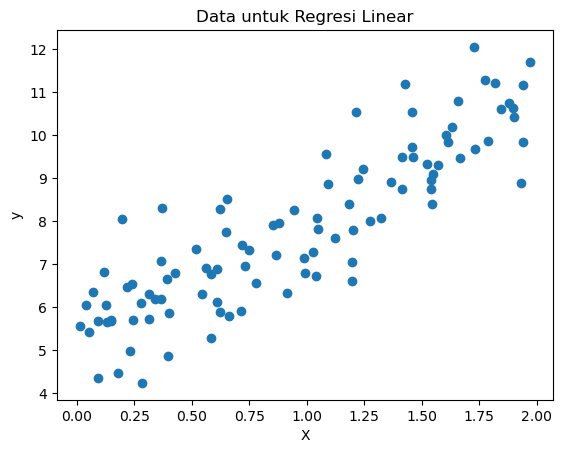

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + 1 + np.random.randn(100, 1)

plt.scatter(X, y)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Data untuk Regresi Linear')
plt.show()

### Regresi Linier

**Tujuan:** Mengimplementasikan regresi linier sederhana tanpa menggunakan library Machine Learning (seperti scikit-learn).

**Model Regresi Linier**: 
$$\hat{y} = w_0 + w_1 x$$

Gunakan **gradient descent** untuk memperbarui parameter $w_0$ dan $w_1$.
Fungsi loss yang digunakan adalah **Mean Squared Error (MSE)**:
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

w0: 5.21509615754674, w1: 2.770113386438491


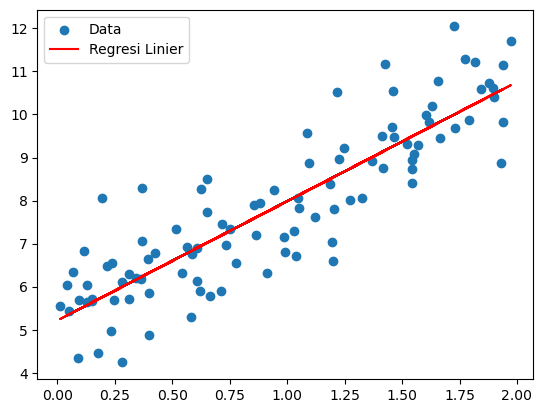

In [3]:
w0 = 0
w1 = 0
alpha = 0.1
epochs = 1000
m = len(X)

# gradient descent
for epoch in range(epochs):
    y_pred = w0 + w1 * X
    error = y_pred - y
    grad0 = (2/m) * np.sum(error)
    grad1 = (2/m) * np.sum(error * X)

    w0 -= alpha * grad0
    w1 -= alpha * grad1

print(f"w0: {w0}, w1: {w1}")
plt.scatter(X, y, label="Data")
plt.plot(X, w0 + w1 * X, color='red', label="Regresi Linier")
plt.legend()
plt.show()

### Regresi Polinomial

**Tujuan:** Mengimplementasikan regresi polinomial derajat dua.

**Model Polinomial**: 
$$\hat{y} = w_0 + w_1 x + w_2 x^2$$

w:  [5.55515121 1.65674021 0.57244352]


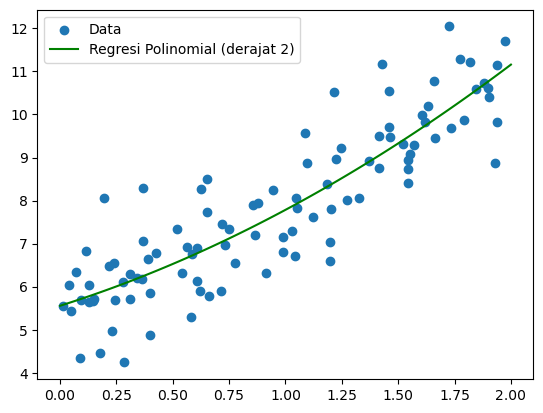

In [6]:
# buat fitur polinomial
X_poly = np.hstack((np.ones((m, 1)), X, X**2))
w = np.zeros((X_poly.shape[1], 1))

# gradien descent
for epoch in range(epochs):
    y_pred = X_poly @ w
    error = y_pred - y
    gradients = (2/m) * X_poly.T @ error
    w -= alpha * gradients

print("w: ", w.ravel())

x_plot = np.linspace(0, 2, 100).reshape(-1, 1)
x_poly_plot = np.hstack((np.ones_like(x_plot), x_plot, x_plot**2))
y_plot = x_poly_plot @ w

plt.scatter(X, y, label="Data")
plt.plot(x_plot, y_plot, color='green', label="Regresi Polinomial (derajat 2)")
plt.legend()
plt.show()